In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.optimizers import SGD
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# 记录开始时间
start_time = time.time()

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 100

data_transforms = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.3)

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'

train_generator = data_transforms.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training')

test_generator = data_transforms.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation')
# 将训练集转换为NumPy数组并打乱顺序
train_data = []
train_labels = []
for i in range(len(train_generator)):
    batch_data, batch_labels = train_generator[i]
    train_data.append(batch_data)
    train_labels.append(batch_labels)
train_data = np.concatenate(train_data)
train_labels = np.concatenate(train_labels)
train_data, train_labels = shuffle(train_data, train_labels)

# 将测试集转换为NumPy数组并打乱顺序
test_data = []
test_labels = []
for i in range(len(test_generator)):
    batch_data, batch_labels = test_generator[i]
    test_data.append(batch_data)
    test_labels.append(batch_labels)
test_data = np.concatenate(test_data)
test_labels = np.concatenate(test_labels)
test_data, test_labels = shuffle(test_data, test_labels)

Found 518 images belonging to 4 classes.
Found 220 images belonging to 4 classes.


In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 加载预训练的NASNetMobile模型
base_model = keras.applications.NASNetMobile(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 冻结预训练模型的权重
base_model.trainable = False

# 添加自定义的分类层
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(4, activation='softmax')
])

# 编译模型
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 训练模型
history = model.fit(train_data, train_labels, epochs=num_epochs, validation_data=(test_data, test_labels))

# 输出损失率和准确率到txt文件
with open('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result_file_NASNetMobile.txt', 'w') as file:
    file.write('Epoch\tTrain Loss\tTrain Accuracy\tTest Loss\tTest Accuracy\n')
    for epoch in range(num_epochs):
        file.write('{}\t{:.4f}\t{:.4f}\t{:.4f}\t{:.4f}\n'.format(
            epoch, history.history['loss'][epoch], history.history['accuracy'][epoch],
            history.history['val_loss'][epoch], history.history['val_accuracy'][epoch])
        )

Epoch 1/100
17/17 [==============================] - 15s 888ms/step - loss: 1.2738 - accuracy: 0.3938 - val_loss: 1.2009 - val_accuracy: 0.4364
Epoch 2/100
17/17 [==============================] - 12s 686ms/step - loss: 0.9598 - accuracy: 0.6293 - val_loss: 1.0664 - val_accuracy: 0.5636
Epoch 3/100
17/17 [==============================] - 12s 679ms/step - loss: 0.8029 - accuracy: 0.7162 - val_loss: 0.9432 - val_accuracy: 0.6318
Epoch 4/100
17/17 [==============================] - 12s 684ms/step - loss: 0.6969 - accuracy: 0.7896 - val_loss: 0.8952 - val_accuracy: 0.6136
Epoch 5/100
17/17 [==============================] - 12s 682ms/step - loss: 0.6209 - accuracy: 0.8205 - val_loss: 0.8430 - val_accuracy: 0.6500
Epoch 6/100
17/17 [==============================] - 12s 684ms/step - loss: 0.5606 - accuracy: 0.8514 - val_loss: 0.8096 - val_accuracy: 0.6591
Epoch 7/100
17/17 [==============================] - 12s 691ms/step - loss: 0.5156 - accuracy: 0.8571 - val_loss: 0.7692 - val_accuracy:

In [3]:
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

1259.3571257591248


In [4]:
model.save_weights('NASNetMobile_weights.h5') 

In [2]:
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


base_model = keras.applications.NASNetMobile(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 冻结预训练模型的权重
base_model.trainable = False

# 添加自定义的分类层
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(4, activation='softmax')
])
model.load_weights('NASNetMobile_weights.h5')

start_time = time.time()
# 对测试集进行预测
y_pred = model.predict(test_data)
y_pred = np.argmax(y_pred, axis=1)  # 将预测的概率转换为类别标签
test_labels = np.argmax(test_labels, axis=1)
print(y_pred,test_labels)
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(test_labels))

[2 1 3 0 0 3 3 3 1 0 2 1 3 2 1 3 3 2 1 3 3 2 1 0 1 1 2 3 0 0 2 1 1 0 1 1 1
 3 1 0 1 3 3 2 2 3 1 3 3 2 1 3 3 0 1 1 0 0 1 0 0 2 0 2 1 1 0 3 1 2 3 3 2 1
 0 0 0 1 1 1 2 0 1 0 3 2 0 0 1 1 1 1 3 0 3 1 2 2 1 3 0 1 3 1 1 2 1 3 0 0 0
 3 0 2 0 2 2 2 1 0 0 0 3 1 3 0 3 0 1 1 1 3 2 3 0 3 0 2 2 1 0 2 0 1 1 3 2 3
 0 0 2 1 2 3 0 2 1 0 1 2 3 0 3 0 1 1 2 1 1 2 2 3 2 3 0 1 3 3 1 2 0 3 3 1 1
 3 3 2 3 1 2 0 0 1 0 3 2 2 0 3 0 3 2 3 3 1 1 2 3 1 3 2 1 3 0 2 3 3 3 1] [2 1 0 0 3 3 3 0 1 0 2 0 2 2 1 0 3 2 1 3 3 2 2 1 0 1 2 1 0 0 2 1 0 1 3 0 1
 3 2 0 1 2 3 2 2 0 1 3 3 2 1 3 3 3 3 0 1 0 1 0 0 2 3 2 3 3 1 3 1 2 0 0 2 1
 3 3 0 1 1 1 2 0 1 0 3 2 3 0 1 1 0 1 3 0 3 1 2 2 1 3 0 1 3 1 1 2 1 0 2 0 3
 3 1 2 0 2 2 2 1 2 0 0 1 1 3 0 3 0 1 2 0 3 2 0 0 3 0 2 2 1 0 2 0 1 1 3 2 3
 0 0 2 1 2 0 0 2 1 0 1 2 3 1 3 0 1 1 2 2 1 2 2 3 2 3 0 1 3 3 1 2 0 0 3 1 1
 3 3 2 1 1 2 0 3 1 0 0 2 2 0 3 3 0 2 3 3 1 0 2 3 1 3 2 0 2 0 2 3 3 3 1]
0.032552760297601874


In [9]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 17
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('NASNetMobile_con.png', dpi=300)
    plt.tight_layout()

In [10]:
cnf_matrix = confusion_matrix(y_pred,test_labels)
print(cnf_matrix)

[[35  6  2  9]
 [ 9 47  4  4]
 [ 0  0 45  0]
 [12  3  3 41]]


Normalized confusion matrix
[[0.67307692 0.11538462 0.03846154 0.17307692]
 [0.140625   0.734375   0.0625     0.0625    ]
 [0.         0.         1.         0.        ]
 [0.20338983 0.05084746 0.05084746 0.69491525]]


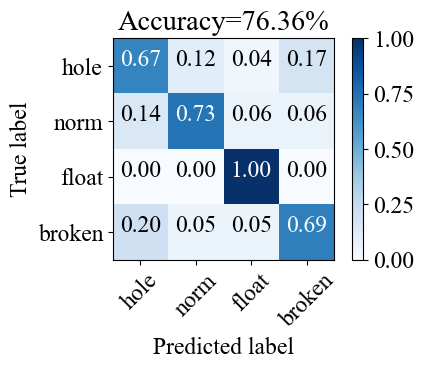

In [11]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_pred,test_labels)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)